In [59]:
!pip install ultralytics

In [60]:
!pip install opencv-python torch torchvision albumentations

In [61]:
from ultralytics import YOLO
import numpy as np
from PIL import Image
import requests
from io import BytesIO
import cv2
import zipfile
import tarfile
import os
import pandas as pd
import json
import yaml
import cv2
import matplotlib.pyplot as plt
%matplotlib inline

In [62]:
# def afficher_segmentation_yolo(modele_path: str, image_path: str):
#     """
#     Charge un modèle YOLOv8 de type segmentation, effectue une prédiction sur l'image,
#     puis affiche l'image avec les masques de segmentation.

#     Args:
#         modele_path (str): Chemin vers le modèle YOLOv8 (./).
#         image_path (str): Chemin vers l'image à analyser.
#     """
#     # Charger le modèle
#     model = YOLO(modele_path)

#     # Prédiction
#     results = model(image_path)
#     result = results[0]

#     # Générer l'image avec les masques
#     output_image = result.plot()
#     output_image_rgb = cv2.cvtColor(output_image, cv2.COLOR_BGR2RGB)

#     # Afficher
#     plt.figure(figsize=(10, 10))
#     plt.imshow(output_image_rgb)
#     plt.axis('off')
#     plt.title("Masques de segmentation YOLOv8")
#     plt.show()

In [63]:
# # Exemple d'utilisation
# afficher_segmentation_yolo(
#     modele_path="C:/Users/fanch/OneDrive/Bureau/Data_science/01_Jedha/Projets/Projet_final/dataset_jej_unzip_v2/model/calcul/best (1).pt",
#     image_path="C:/Users/fanch/OneDrive/Bureau/Data_science/01_Jedha/Projets/Projet_final/dataset_jej_unzip_v2/model/calcul/00005858.jpg",
#     )

### DEBUT MODEL

In [64]:
import cv2
import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
from ultralytics import YOLO

def segmenter_et_calculer_aires_v5(model_path: str, image_path: str, yaml_path: str):
    """
    YOLOv8-seg : affiche l'image originale + image avec masques,
    retourne aussi le DataFrame avec :
    - class_id, label, area_pixels, percent_total, confidence
    """
    # Charger les noms de classes depuis le YAML
    with open(yaml_path, "r") as f:
        data_yaml = yaml.safe_load(f)
    class_names = data_yaml.get("names", {})

    # Charger le modèle
    model = YOLO(model_path)

    # Charger et préparer l'image d'origine
    original_bgr = cv2.imread(image_path)
    if original_bgr is None:
        raise FileNotFoundError(f"Image non trouvée : {image_path}")
    original_rgb = cv2.cvtColor(original_bgr, cv2.COLOR_BGR2RGB)

    # Prédiction
    results = model(image_path)
    result = results[0]

    # Image annotée (masques + boxes)
    output_image = result.plot()
    output_image_rgb = cv2.cvtColor(output_image, cv2.COLOR_BGR2RGB)

    # Affichage : original + annoté
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(original_rgb)
    plt.title("Image originale")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(output_image_rgb)
    plt.title("Segmentation YOLOv8")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    # Aucun masque détecté
    if result.masks is None:
        df = pd.DataFrame(columns=["class_id", "label", "area_pixels", "percent_total", "confidence"])
        return output_image_rgb, df

    masks = result.masks.data.cpu().numpy()
    num_masks = masks.shape[0]

    total_area = 0
    mask_infos = []

    for i in range(num_masks):
        class_id = int(result.boxes.cls[i].item())
        if isinstance(class_names, list):
            label = class_names[class_id]
        else:
            label = class_names.get(class_id, f"class_{class_id}")

        mask = masks[i]
        mask_bin = (mask > 0.5).astype(np.uint8)
        area = int(mask_bin.sum())
        confidence = float(result.boxes.conf[i].item())
        total_area += area
        mask_infos.append((class_id, label, area, confidence))

    # Construire le DataFrame
    data = []
    for class_id, label, area, confidence in mask_infos:
        percent = (area / total_area) * 100 if total_area > 0 else 0
        data.append({
            "class_id": class_id,
            "label": label,
            "area_pixels": area,
            "percent_total": round(percent, 2),
            "confidence": round(confidence, 3)
        })

    df = pd.DataFrame(data)

    return output_image_rgb, df


In [65]:
def enrichir_avec_poids(df_yolo: pd.DataFrame, estimator: float = 500):
    """
    Calcule le poids estimé de chaque aliment en fonction du pourcentage de surface.

    Args:
        df_yolo (pd.DataFrame): DataFrame YOLOv8 contenant `label` et `percent_total`
        estimator (float): Poids total estimé de l’assiette (en grammes)

    Returns:
        tuple:
            - liste des labels détectés
            - DataFrame enrichi avec une colonne `poids` (en grammes)
    """
    # 1. Extraire les labels
    labels_detectes = df_yolo["label"].tolist()

    # 2. Calcul du poids estimé
    df_yolo = df_yolo.copy()
    df_yolo["poids"] = (df_yolo["percent_total"] / 100) * estimator
    df_yolo["poids"] = df_yolo["poids"].round(1)

    return labels_detectes, df_yolo


In [66]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

image 1/1 /content/drive/My Drive/Calcul/images/test/00005817.jpg: 640x640 1 chicken duck, 2 tomatos, 1 lettuce, 29510.4ms
Speed: 10.8ms preprocess, 29510.4ms inference, 28.7ms postprocess per image at shape (1, 3, 640, 640)


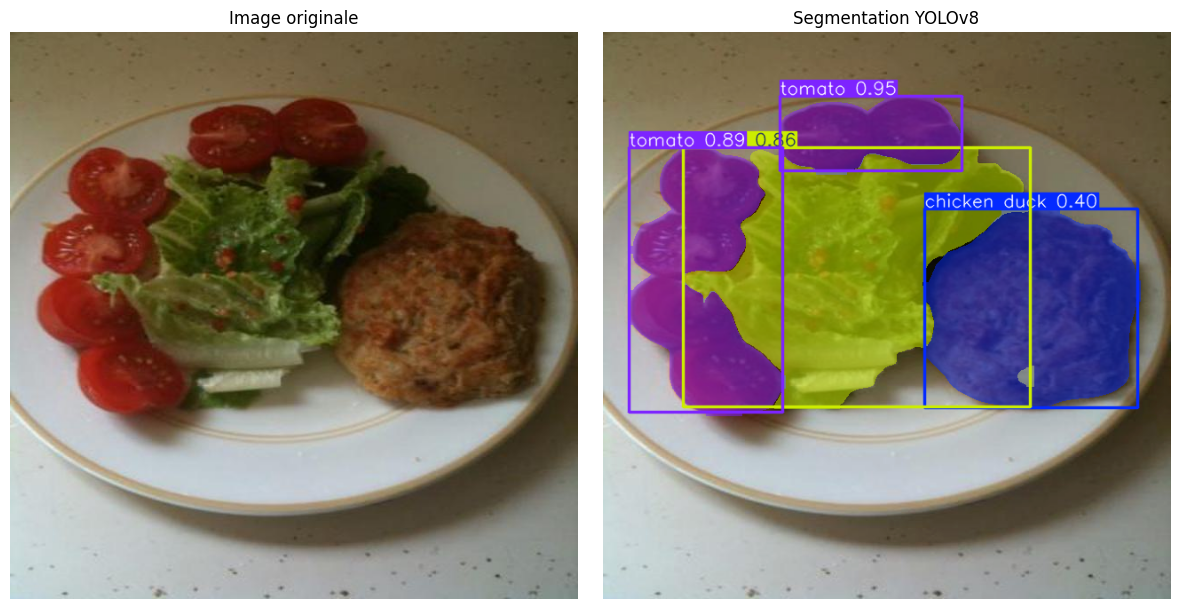

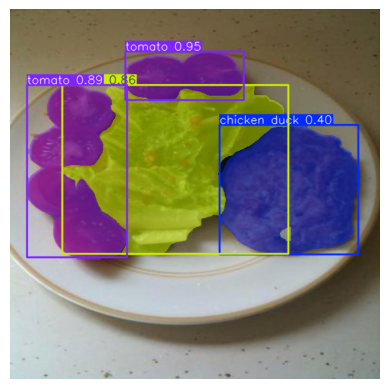

   class_id         label  area_pixels  percent_total  confidence
0        15        tomato        13713           9.14       0.955
1        15        tomato        31226          20.82       0.886
2        27       lettuce        61717          41.15       0.856
3         0  chicken duck        43316          28.88       0.403


In [67]:
from google.colab import drive
import matplotlib.pyplot as plt

# Monter Google Drive
drive.mount('/content/drive')

# Exécuter la fonction avec les chemins corrects
img, df_yolo = segmenter_et_calculer_aires_v5(
    model_path="/content/drive/My Drive/final_project/yolov8x-seg-finetune-freeze-last3/weights/best.pt",  # Chemin du modèle
    image_path="/content/drive/My Drive/Calcul/images/test/00005817.jpg",  # Chemin de l'image
    yaml_path="/content/drive/My Drive/final_project/yolo_v3.yaml"  # Chemin du fichier .yaml
)

# Afficher l'image segmentée
plt.imshow(img)
plt.axis("off")
plt.show()

# Afficher le dataframe des résultats YOLO
print(df_yolo)




In [68]:
labels, df_enrichi = enrichir_avec_poids(df_yolo, estimator=300)

print("Labels détectés :", labels)
print(df_enrichi)


Labels détectés : ['tomato', 'tomato', 'lettuce', 'chicken duck']
   class_id         label  area_pixels  percent_total  confidence  poids
0        15        tomato        13713           9.14       0.955   27.4
1        15        tomato        31226          20.82       0.886   62.5
2        27       lettuce        61717          41.15       0.856  123.4
3         0  chicken duck        43316          28.88       0.403   86.6


In [69]:
print(labels)


['tomato', 'tomato', 'lettuce', 'chicken duck']


In [70]:
import requests
import time

# Clé API DeepL
API_KEY = "c5e1624a-2cc8-4333-9143-2c3374ca0145:fx"
DEEPL_URL = "https://api-free.deepl.com/v2/translate"

def traduire_liste_avec_deepl(liste_mots, source_lang="EN", target_lang="FR", sleep_time=1.2):
    """
    Traduit une liste de mots avec DeepL et retourne une liste de traductions.

    Args:
        liste_mots (list): liste de mots ou expressions à traduire
        source_lang (str): langue source (ex: 'EN')
        target_lang (str): langue cible (ex: 'FR')
        sleep_time (float): pause entre les requêtes pour respecter l'API

    Returns:
        list: liste des mots traduits dans le même ordre
    """
    liste_traductions = []

    for i, mot in enumerate(liste_mots):
        if mot:
            print(f"Traduction {i+1}/{len(liste_mots)} : {mot}")
            response = requests.post(
                DEEPL_URL,
                data={
                    "auth_key": API_KEY,
                    "text": mot,
                    "source_lang": source_lang,
                    "target_lang": target_lang
                }
            )
            if response.status_code == 200:
                traduit = response.json()["translations"][0]["text"]
            else:
                print(f"❌ Erreur pour '{mot}':", response.text)
                traduit = None

            liste_traductions.append(traduit)
            time.sleep(sleep_time)

    return liste_traductions


labels_en = labels
labels_fr = traduire_liste_avec_deepl(labels_en)

print("Traductions :", labels_fr)

Traduction 1/4 : tomato
Traduction 2/4 : tomato
Traduction 3/4 : lettuce
Traduction 4/4 : chicken duck
Traductions : ['tomate', 'tomate', 'laitue', 'poulet canard']


In [71]:
from sentence_transformers import SentenceTransformer
from tensorflow import keras

model = SentenceTransformer("all-MiniLM-L6-v2")

labels_embeddings = model.encode(labels_fr)

In [72]:
labels_embeddings #labels en sortie du model YOLO après l'embedding

array([[   -0.10211,    0.053491,    0.059844, ...,   -0.023391,    0.065494,   -0.047075],
       [   -0.10211,    0.053491,    0.059844, ...,   -0.023391,    0.065494,   -0.047075],
       [ 0.00070492,   -0.028316,    -0.02206, ...,  -0.0024828,    0.068133,    0.020344],
       [  -0.027045,    0.048775,   -0.095074, ...,   -0.017917,    0.077502,    0.068521]], dtype=float32)

In [73]:
# Ajouter les embeddings comme une nouvelle colonne
df_enrichi['embedding'] = list(labels_embeddings)

# Afficher le DataFrame avec les embeddings ajoutés
print(df_enrichi)

   class_id         label  area_pixels  percent_total  confidence  poids  \
0        15        tomato        13713           9.14       0.955   27.4   
1        15        tomato        31226          20.82       0.886   62.5   
2        27       lettuce        61717          41.15       0.856  123.4   
3         0  chicken duck        43316          28.88       0.403   86.6   

                                           embedding  
0  [-0.10211021, 0.05349111, 0.059844162, -0.0771...  
1  [-0.10211021, 0.05349111, 0.059844162, -0.0771...  
2  [0.000704925, -0.028316177, -0.022059957, 0.01...  
3  [-0.027044738, 0.048774816, -0.09507357, -0.07...  


In [74]:
# Mettre à jour le chemin du fichier CSV
ig_table = pd.read_csv('/content/drive/My Drive/final_project/ig_table.csv')

# Afficher les premières lignes du dataframe
ig_table.head()


,Aliment,IG
0,abricot frais,30.0
1,abricot sec,35.0
2,abricot au sirop,55.0
3,ail,30.0
4,airelle rouge,45.0


In [75]:
aliment_to_embed = [ch for ch in ig_table['Aliment']]
aliment_to_embed[:15]

['abricot frais',
 'abricot sec',
 'abricot au sirop',
 'ail',
 'airelle rouge',
 'amande',
 'ananas frais',
 'ananas au sirop',
 'arachide',
 'artichaut',
 'asperge',
 'aubergine',
 'avocat',
 'banane verte',
 'banane mûre']

In [76]:
model = SentenceTransformer("all-MiniLM-L6-v2")

embeddings_aliments = model.encode(aliment_to_embed)
embeddings_aliments[:15] #embeddings de la table ig_table

array([[  -0.096728,  -0.0068154,   -0.047541, ...,    0.030809,    0.074584,   -0.021836],
       [  -0.098149,   -0.027547,   -0.053424, ...,   -0.015224,    0.011865,   -0.050249],
       [ -0.0038608,    0.021107,   -0.055518, ...,    0.015749,    0.021455,   -0.028774],
       ...,
       [  -0.041413,   0.0041799,    -0.03943, ...,   -0.053531,     0.02628,     0.12832],
       [  0.0036822,    0.046994,    -0.12411, ...,    0.034302,    0.023113,    -0.11361],
       [  -0.049294,   0.0020107,   -0.022875, ...,   -0.054103,   0.0074296,   -0.084822]], dtype=float32)

In [77]:
ig_table['aliments_embedding'] = embeddings_aliments.tolist()
ig_table.head()

,Aliment,IG,aliments_embedding
0,abricot frais,30.0,"[-0.09672834724187851, -0.006815427914261818, ..."
1,abricot sec,35.0,"[-0.09814923256635666, -0.027547087520360947, ..."
2,abricot au sirop,55.0,"[-0.0038607700262218714, 0.02110731229186058, ..."
3,ail,30.0,"[-0.09047166258096695, 0.015997514128684998, 0..."
4,airelle rouge,45.0,"[-0.006428626831620932, -0.058962300419807434,..."


In [78]:
from sklearn.metrics.pairwise import cosine_similarity

# Extraction des embeddings
embeddings1 = np.stack(df_enrichi['embedding'].values)
embeddings2 = np.stack(ig_table['aliments_embedding'].values)

# Calcul des similarités cosinus
similarities = cosine_similarity(embeddings1, embeddings2)

# Trouver le meilleur match pour chaque aliment de df1
matched_indices = np.argmax(similarities, axis=1)
df_enrichi['index_glycemique'] = ig_table.iloc[matched_indices]['IG'].values

# Affichage du résultat
print(df_enrichi[['label', 'poids', 'percent_total', 'confidence', 'index_glycemique']])

          label  poids  percent_total  confidence  index_glycemique
0        tomato   27.4           9.14       0.955              30.0
1        tomato   62.5          20.82       0.886              30.0
2       lettuce  123.4          41.15       0.856              30.0
3  chicken duck   86.6          28.88       0.403               0.0


In [79]:
df_enrichi['nbre_glucides'] = (df_enrichi['poids']*df_enrichi['index_glycemique']) / 100
df_enrichi.head()

,class_id,label,area_pixels,percent_total,confidence,poids,embedding,index_glycemique,nbre_glucides
0,15,tomato,13713,9.14,0.955,27.4,"[-0.10211021, 0.05349111, 0.059844162, -0.0771...",30.0,8.22
1,15,tomato,31226,20.82,0.886,62.5,"[-0.10211021, 0.05349111, 0.059844162, -0.0771...",30.0,18.75
2,27,lettuce,61717,41.15,0.856,123.4,"[0.000704925, -0.028316177, -0.022059957, 0.01...",30.0,37.02
3,0,chicken duck,43316,28.88,0.403,86.6,"[-0.027044738, 0.048774816, -0.09507357, -0.07...",0.0,0.00


In [80]:
# A DEPLACER POUR EXECUTER AVANT EMBEDDING SORTIE YOLO
df_enrichi['label_cooked'] = df_enrichi['label'] + " " + "cooked"
df_enrichi.head()

,class_id,label,area_pixels,percent_total,confidence,poids,embedding,index_glycemique,nbre_glucides,label_cooked
0,15,tomato,13713,9.14,0.955,27.4,"[-0.10211021, 0.05349111, 0.059844162, -0.0771...",30.0,8.22,tomato cooked
1,15,tomato,31226,20.82,0.886,62.5,"[-0.10211021, 0.05349111, 0.059844162, -0.0771...",30.0,18.75,tomato cooked
2,27,lettuce,61717,41.15,0.856,123.4,"[0.000704925, -0.028316177, -0.022059957, 0.01...",30.0,37.02,lettuce cooked
3,0,chicken duck,43316,28.88,0.403,86.6,"[-0.027044738, 0.048774816, -0.09507357, -0.07...",0.0,0.00,chicken duck cooked


In [81]:
# from sklearn.metrics.pairwise import cosine_similarity
# import numpy as np
# import pandas as pd

# def trouver_correspondances_avec_IG(labels_embeddings, ig_table, colonne_embedding="aliments_embedding", colonne_ig="IG"):
#     """
#     Pour chaque vecteur, retourne l'index de la ligne la plus similaire du DataFrame,
#     le score de similarité, et la valeur de IG correspondante.

#     Args:
#         labels_embeddings (list of np.array): liste de vecteurs d'entrée
#         ig_table (pd.DataFrame): DataFrame contenant les colonnes d'embedding et IG
#         colonne_embedding (str): nom de la colonne contenant les embeddings
#         colonne_ig (str): nom de la colonne IG dans le DataFrame

#     Returns:
#         list of dicts: [
#             {
#                 'input_index': i,
#                 'best_match_index': index dans df,
#                 'similarity': score,
#                 'IG': valeur correspondante
#             }, ...
#         ]
#     """
#     resultats = []

#     # Conversion en matrice numpy
#     matrice_df = np.vstack(ig_table[colonne_embedding].values)

#     for i, vec in enumerate(labels_embeddings):
#         vec = np.array(vec).reshape(1, -1)
#         scores = cosine_similarity(vec, matrice_df)[0]
#         idx_max = np.argmax(scores)
#         score_max = scores[idx_max]

#         index_df = ig_table.index[idx_max]
#         ig_value = ig_table.loc[index_df, colonne_ig] if colonne_ig in ig_table.columns else None

#         resultats.append({
#             "input_index": i,
#             "best_match_index": index_df,
#             "similarity": round(score_max, 4),
#             "IG": ig_value
#         })

#     return resultats

In [82]:
# correspondances = trouver_correspondances_avec_IG(labels_embeddings, ig_table)

# for match in correspondances:
#     print(f"🔍 Vecteur {match['input_index']} → ligne {match['best_match_index']}, IG = {match['IG']}, similarité = {match['similarity']}")

In [85]:
from ultralytics import YOLO

yolo_model = YOLO("/content/drive/My Drive/final_project/yolov8x-seg-finetune-freeze-last3/weights/best.pt")
results = yolo_model.predict(image_path)

#📁 Dossier contenant les images
image_folder = "/content/drive/My Drive/Calcul/images/Sample/"

# 📁 Dossier contenant les fichiers .txt de labels (ground truth)
label_folder = "/content/drive/My Drive/Calcul/labels/Sample/"

# 📦 Liste pour stocker les résultats avec aire
results_list = []

# 🔁 Traiter chaque image
for img_name in os.listdir(image_folder):
    if img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
        image_path = os.path.join(image_folder, img_name)
        results = model.predict(image_path)
        for result in results:
            for i, box in enumerate(result.boxes):
                label = result.names[int(box.cls)]
                conf = float(box.conf)
                xyxy = box.xyxy.tolist()[0]
                x1, y1, x2, y2 = xyxy
                # 🎯 Calcul de l'aire (en pixels)
                area = (x2 - x1) * (y2 - y1)
                results_list.append({
                    "image": img_name,
                    "label": label,
                    "confidence": conf,
                    "bbox": xyxy,
                    "area_pixels": area
                })

df_results = pd.DataFrame(results_list)
print(df_results.head())


image 1/1 /content/drive/My Drive/Calcul/images/Sample/Copy of 00005817.jpg: 640x640 1 chicken duck, 2 tomatos, 1 lettuce, 6122.6ms
Speed: 4.0ms preprocess, 6122.6ms inference, 19.5ms postprocess per image at shape (1, 3, 640, 640)


AttributeError: 'SentenceTransformer' object has no attribute 'predict'

In [ ]:
df_results = pd.DataFrame(results_list)
print(df_results[["image", "label", "confidence", "area_pixels"]].head())


In [ ]:
import os

# 📁 Dossier contenant les fichiers .txt de labels (ground truth)
label_folder = "/content/drive/My Drive/Calcul/labels/Sample/"

# 📌 Stocker les classes réelles par image
ground_truth = {}

# 🔁 Parcourir chaque fichier .txt
for file in os.listdir(label_folder):
    if file.endswith(".txt"):
        image_name = file.replace(".txt", ".jpg")  # tu as dit que les images sont en .jpg
        with open(os.path.join(label_folder, file), "r") as f:
            lines = f.readlines()
            class_ids = [int(line.split()[0]) for line in lines if line.strip()]
            ground_truth[image_name] = class_ids

# 👀 Vérifions un échantillon
print("Exemple de ground truth :", list(ground_truth.items())[:5])


In [ ]:
# les deux étapes précédentes c'était pour : ✅ Les prédictions du modèle YOLO (dans df_results)

#✅ Les vérités terrain (ground truths) chargées depuis les fichiers .txt

In [ ]:
pip install numpy scikit-learn seaborn matplotlib


In [ ]:

# 🔍 Faire correspondre les prédictions avec les vraies classes
y_true = []
y_pred = []

for result in results_list:
    img_name = result["image"]
    pred_label = result["label"]
    if img_name in ground_truth:
        true_labels = ground_truth[img_name]
        y_true.extend(true_labels)
        y_pred.append(pred_label)


In [ ]:
# Afficher les noms de classes définis par le modèle
print("Noms de classes définis par le modèle :", model.names)


In [ ]:
{name: idx for idx, name in model.names.items()}

In [ ]:
import os

# 📁 Dossier contenant les images
image_folder = "/content/drive/My Drive/Calcul/images/Sample/"

# 📁 Dossier contenant les fichiers .txt de labels (ground truth)
label_folder = "/content/drive/My Drive/Calcul/labels/Sample/"

# 📦 Liste pour stocker les résultats avec aire
results_list = []

# 🔁 Traiter chaque image
for img_name in os.listdir(image_folder):
    if img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
        image_path = os.path.join(image_folder, img_name)
        results = model(image_path)
        for result in results:
            for i, box in enumerate(result.boxes):
                label = result.names[int(box.cls)]
                conf = float(box.conf)
                xyxy = box.xyxy.tolist()[0]
                x1, y1, x2, y2 = xyxy
                # 🎯 Calcul de l'aire (en pixels)
                area = (x2 - x1) * (y2 - y1)
                results_list.append({
                    "image": img_name,
                    "label": label,
                    "confidence": conf,
                    "bbox": xyxy,
                    "area_pixels": area
                })